# Analisis Tren Penjualan

## Metodologi

1. Memuat data hasil agregasi dari PostgreSQL.
2. Memvisualisasikan data.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('Data/superstore_monthly_sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')

## Visualisasi Tren Penjualan

Memvisualisasikan penjualan bulanan untuk mengidentifikasi tren jangka panjang.

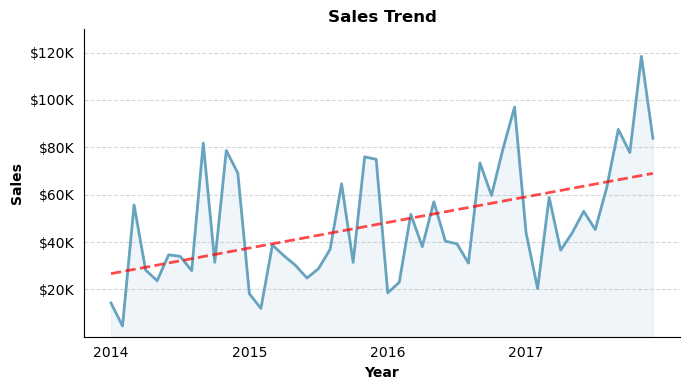

In [2]:
plt.figure(figsize=(7,4))
sns.lineplot(x=range(len(df)), y=df['sales'], ls='-', lw=2, color='#66A3BF', alpha=1)
plt.fill_between(x=np.array(range(len(df))), y1=df['sales'], color='#66A3BF', alpha=0.1)
sns.regplot(x=np.array(range(len(df))), y=df['sales'], scatter=False, ci=None,
            line_kws={'ls':'--', 'lw':2, 'color':'red', 'alpha':0.7})

title_dict = {'family':plt.rcParams['font.family'],
              'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':5,
              'alpha':1}

label_dict = {'x':
              {'family':plt.rcParams['font.family'],
              'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'alpha':1}, 
              
              'y':
              {'family':plt.rcParams['font.family'],
              'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1}}

plt.title('Sales Trend', **title_dict)
plt.xlabel('Year', **label_dict['x'])
plt.ylabel('Sales', **label_dict['y'])

ax = plt.gca()
ax.tick_params(which='major', axis='both', left=False, bottom=False)
ax.set_xticks(ticks=range(0, len(df), 12), labels=df['order_year'].unique())
ax.set_yticks(ticks=ax.get_yticks()[2:-1])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1_000:.0f}K'))
ax.set_ylim(0, 130_000)

plt.grid(which='major', axis='y', ls='--', alpha=0.5)
plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()